# CLIP 3D Spatial Relationships

## init

In [230]:
from transformers import CLIPModel, CLIPProcessor
from PIL import Image
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.nn import BCEWithLogitsLoss
from torch.optim import AdamW
from dataloader import create_dataloader, SpatialDataset
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm 
from sklearn.metrics import confusion_matrix
import numpy as np
import json

from utils import *
from config import *

device = "cuda" if torch.cuda.is_available() else "cpu"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [127]:
a = np.array([[1,2], [3,4]])
a.flatten()

array([1, 2, 3, 4])

## clip model

In [128]:
model = CLIPModel.from_pretrained(CLIP_MODEL_NAME)
processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
model.eval()

CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPSdpaAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e

In [129]:
image = Image.open("data/apple.jpg")
text = "a red gala apple"

# preprocess
inputs = processor(text=[text], images=[image], return_tensors="pt", padding=True)

# encode
with torch.no_grad():
    outputs = model(**inputs)
    image_emb = outputs.image_embeds
    text_emb = outputs.text_embeds

UnidentifiedImageError: cannot identify image file 'C:\\Users\\vince\\git\\6.8300\\project\\data\\apple.jpg'

In [ ]:
outputs.keys()

odict_keys(['logits_per_image', 'logits_per_text', 'text_embeds', 'image_embeds', 'text_model_output', 'vision_model_output'])

## data & feature extraction

data filepath format: `<c/nc>_<per_train>_<c/nc>_<per_valid>`

1. determine which predicates to test
1. for each sample within the filtered predicates, get the following clip embeddings:
    * full image embedding
    * subject text emb
    * objext text emb
    * predicate text emb
    * depth image embedding (in case we end up using it)
1. create individual datasets for each predicate, each with the following keys:
    * image_emb
    * subject_emb
    * object_emb
    * predicate_emb
    * depth_emb
    * weight (weight from sample, in case we end up using it)
1. for attention map analysis: probably fine to just analyze a random sample(s) from each predicate, don't need to track attention maps for each sample 

* experiment with cropped vs uncropped images?
* experiment with holding out certain objects for testing? 


**sample keys**
* `subject`:
    * object name
    * object idx
    * bounding box
    * camera pose tensor (t) (?) 
* `object`:
    * same as `subject`
* `predicate`:
    * predicate name
    * predicate idx
    * bbox
* `label`:
    * True/False, whether predicate holds
* `rgb_source`:
    * data path to original photo, likely path in gcp bucket
* `weight`:
    * ??? weight for correctness of label?
* `img_crop`:
    * rbg img
* `depth_crop`:
    * depth img
* `bbox_mask`:
    * mask for bounding box 

In [130]:
default_dataset_args = {
    "split": 'train',
    "predicate_dim": 30,
    "object_dim": 67,
    "data_path": 'data/c_0.9_c_0.1.json',
    "load_img": True,
    "data_aug_shift": False,
    "data_aug_color": False,
    "crop": True,
    "norm_data": False,
    "resize_mask": False,
    "trans_vec": [],
}

train_dataset_args = default_dataset_args | {"split": "train"}
# val_dataset_args = default_dataset_args | {"split": "valid"}
# test_dataset_args = default_dataset_args | {"split": "test"}

train_dl, train_predicates, train_objects = create_dataloader(
    **train_dataset_args,
    num_workers=1,
    batch_size=16,
)
# val_dl, val_predicates, val_objects = create_dataloader(
#     **val_dataset_args,
#     num_workers=1,
#     batch_size=16,
# )
# test_dl, test_predicates, test_objects = create_dataloader(
#     **test_dataset_args,
#     num_workers=1,
#     batch_size=16,
# )

20454 relations in train
Percentage of positive labels  in train: 0.5
Percentage of negative labels  in train: 0.5
{'points away': (284, 284, 0.5), 'to the right of': (161, 161, 0.5), 'around': (326, 326, 0.5), 'to the side of': (515, 515, 0.5), 'to the left of (wrt you)': (509, 509, 0.5), 'touching': (276, 276, 0.5), 'to the left of': (154, 154, 0.5), 'under': (751, 751, 0.5), 'inside': (213, 213, 0.5), 'passing through': (72, 72, 0.5), 'faces away': (495, 495, 0.5), 'far from': (89, 89, 0.5), 'faces towards': (454, 454, 0.5), 'to the side of (wrt you)': (72, 72, 0.5), 'behind': (427, 427, 0.5), 'aligned to': (232, 232, 0.5), 'on top of': (656, 656, 0.5), 'on': (722, 722, 0.5), 'covering': (128, 128, 0.5), 'in front of (wrt you)': (211, 211, 0.5), 'in front of': (410, 410, 0.5), 'leaning against': (330, 330, 0.5), 'near': (225, 225, 0.5), 'below': (466, 466, 0.5), 'points towards': (224, 224, 0.5), 'behind (wrt you)': (266, 266, 0.5), 'to the right of (wrt you)': (477, 477, 0.5), 'in'

In [ ]:
samples_dict = defaultdict(list)

for split in ("train", "valid", "test"):
    split_dataset_args = default_dataset_args | {"split": split}
    split_dataloader, split_predicates, split_objects = create_dataloader(
        **split_dataset_args,
        num_workers=1,
        batch_size=16,
    )

    for batch in split_dataloader:
        # prepare inputs
        images = [image for image in batch["img_crop"]]
        subject_names = batch["subject"]["name"]
        object_names = batch["object"]["name"]
        predicate_names = batch["predicate"]["name"]
        depth_images = [depth_image.repeat(3, 1, 1) for depth_image in batch["depth_crop"]] # duplicate channel dim
        weights = batch["weight"]
        labels = batch["label"]

        # encode images
        image_inputs = processor(images=images, return_tensors="pt").to(device)
        depth_image_inputs = processor(images=depth_images, return_tensors="pt").to(device)
        with torch.no_grad():
            image_embs = model.get_image_features(**image_inputs)
            depth_image_embs = model.get_image_features(**depth_image_inputs)

        # encode text
        subject_inputs = processor(text=subject_names, return_tensors="pt", padding=True).to(device)
        object_inputs = processor(text=object_names, return_tensors="pt", padding=True).to(device)
        predicate_inputs = processor(text=predicate_names, return_tensors="pt", padding=True).to(device)
        with torch.no_grad():
            subject_embs = model.get_text_features(**subject_inputs)
            object_embs = model.get_text_features(**object_inputs)
            predicate_embs = model.get_text_features(**predicate_inputs)

        # construct and sort samples
        for i in range(len(images)):
            if predicate_names[i] in allowed_predicates:
                sample = {
                    "image_emb": image_embs[i],
                    "subject_emb": subject_embs[i],
                    "object_emb": object_embs[i],
                    "predicate_emb": predicate_embs[i],
                    "depth_emb": depth_image_embs[i],
                    "subject_name": subject_names[i],
                    "object_name": object_names[i],
                    "predicate_name": predicate_names[i],
                    "weight": weights[i],
                }
                samples_dict[predicate_names[i]].append(sample)

        break
    break

20454 relations in train
Percentage of positive labels  in train: 0.5
Percentage of negative labels  in train: 0.5
{'to the side of (wrt you)': (72, 72, 0.5), 'far from': (89, 89, 0.5), 'to the left of': (154, 154, 0.5), 'to the side of': (515, 515, 0.5), 'around': (326, 326, 0.5), 'under': (751, 751, 0.5), 'over': (557, 557, 0.5), 'aligned to': (232, 232, 0.5), 'near': (225, 225, 0.5), 'touching': (276, 276, 0.5), 'behind (wrt you)': (266, 266, 0.5), 'behind': (427, 427, 0.5), 'on': (722, 722, 0.5), 'points towards': (224, 224, 0.5), 'faces away': (495, 495, 0.5), 'faces towards': (454, 454, 0.5), 'to the right of': (161, 161, 0.5), 'to the right of (wrt you)': (477, 477, 0.5), 'in front of (wrt you)': (211, 211, 0.5), 'inside': (213, 213, 0.5), 'below': (466, 466, 0.5), 'points away': (284, 284, 0.5), 'leaning against': (330, 330, 0.5), 'outside': (28, 28, 0.5), 'passing through': (72, 72, 0.5), 'covering': (128, 128, 0.5), 'to the left of (wrt you)': (509, 509, 0.5), 'in': (497, 497

Python(62904) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [410]:
from config import *

# count dataset samples
d = defaultdict(dict)
for predicate in allowed_predicates:
    predicate_count = 0
    for split in ("train", "valid", "test"):
        split_samples = torch.load(f"data/predicate_probe_data/{predicate}_{split}.pt")
        d[predicate][split] = len(split_samples)
        predicate_count += len(split_samples)
    d[predicate]["total"] = predicate_count

print(json.dumps(d, indent=2))

with open("data/sample_counts.json", "w") as f:
    json.dump(d, f, indent=2)

{
  "below": {
    "train": 932,
    "valid": 100,
    "test": 148,
    "total": 1180
  },
  "to the left of (wrt you)": {
    "train": 1017,
    "valid": 100,
    "test": 252,
    "total": 1369
  },
  "to the right of (wrt you)": {
    "train": 954,
    "valid": 106,
    "test": 230,
    "total": 1290
  },
  "to the side of": {
    "train": 1029,
    "valid": 100,
    "test": 348,
    "total": 1477
  },
  "on": {
    "train": 1444,
    "valid": 186,
    "test": 232,
    "total": 1862
  },
  "covering": {
    "train": 256,
    "valid": 20,
    "test": 314,
    "total": 590
  },
  "inside": {
    "train": 426,
    "valid": 52,
    "test": 120,
    "total": 598
  },
  "in front of": {
    "train": 820,
    "valid": 84,
    "test": 128,
    "total": 1032
  },
  "behind": {
    "train": 854,
    "valid": 82,
    "test": 66,
    "total": 1002
  },
  "near": {
    "train": 450,
    "valid": 48,
    "test": 238,
    "total": 736
  },
  "far from": {
    "train": 178,
    "valid": 26,
    "tes

In [20]:
samples_dict.keys()

dict_keys(['to the left of (wrt you)', 'below', 'to the right of (wrt you)', 'to the side of', 'behind', 'on'])

In [36]:
for x in train_dl:
    sample = x
    break

sample.keys()

Python(72397) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


dict_keys(['subject', 'object', 'predicate', 'label', 'rgb_source', 'weight', 'img_crop', 'depth_crop', 'bbox_mask'])

## predicate probe training

### image emb only

epoch {epoch+1}/{num_epochs}: 100%|██████████| 100/100 [00:07<00:00, 14.28it/s]

Final train/val loss: 0.6726/0.6895, final train/val acc: 0.6417/0.5488



C:\Users\vince\AppData\Local\Temp\ipykernel_50092\3140016949.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


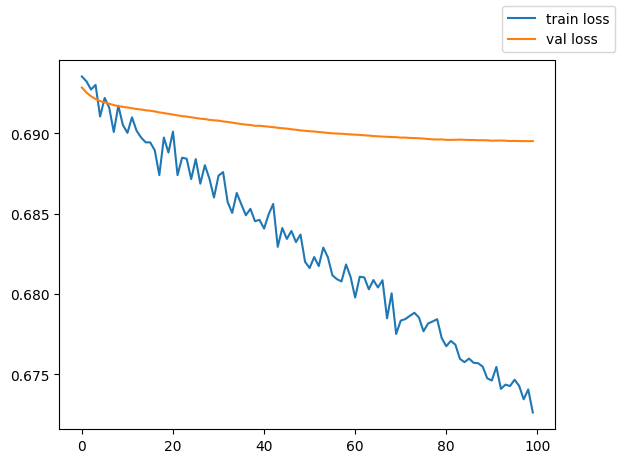

In [81]:
predicate = "behind"

data_file_path = f"{DATA_DIRECTORY}/predicate_probe_data/{predicate}"
train_ds = PredicateProbeDataset(data_file_path + "_train.pt")
train_dl = DataLoader(train_ds, batch_size=16) 
val_ds = PredicateProbeDataset(data_file_path + "_valid.pt")
val_dl = DataLoader(val_ds, batch_size=16) 

mlp_model = MLP(hidden_dim=256)

train_outputs = train(mlp_model, train_dl, val_dl, 
                      num_epochs=100, lr=1e-5, verbose=False)
train_losses, val_losses, train_confusion_matrices, val_confusion_matrices = train_outputs

torch.save(mlp_model.state_dict(), f"{MODEL_DIRECTORY}/test.pt")

# basic plotting
fig, ax = plt.subplots()

ax.plot(train_losses, label="train loss")
ax.plot(val_losses, label="val loss")

fig.legend()
fig.show()

100%|██████████| 150/150 [00:11<00:00, 12.68it/s]


Final train/val loss: 0.6794/0.6923, final train/val acc: 0.6464/0.5244


100%|██████████| 150/150 [00:11<00:00, 12.84it/s]


Final train/val loss: 0.6714/0.6938, final train/val acc: 0.6511/0.5366


100%|██████████| 150/150 [00:11<00:00, 12.80it/s]


Final train/val loss: 0.6593/0.6910, final train/val acc: 0.6651/0.5122


100%|██████████| 150/150 [00:11<00:00, 12.93it/s]
C:\Users\vince\AppData\Local\Temp\ipykernel_50092\1038609305.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Final train/val loss: 0.6461/0.6935, final train/val acc: 0.7014/0.5366


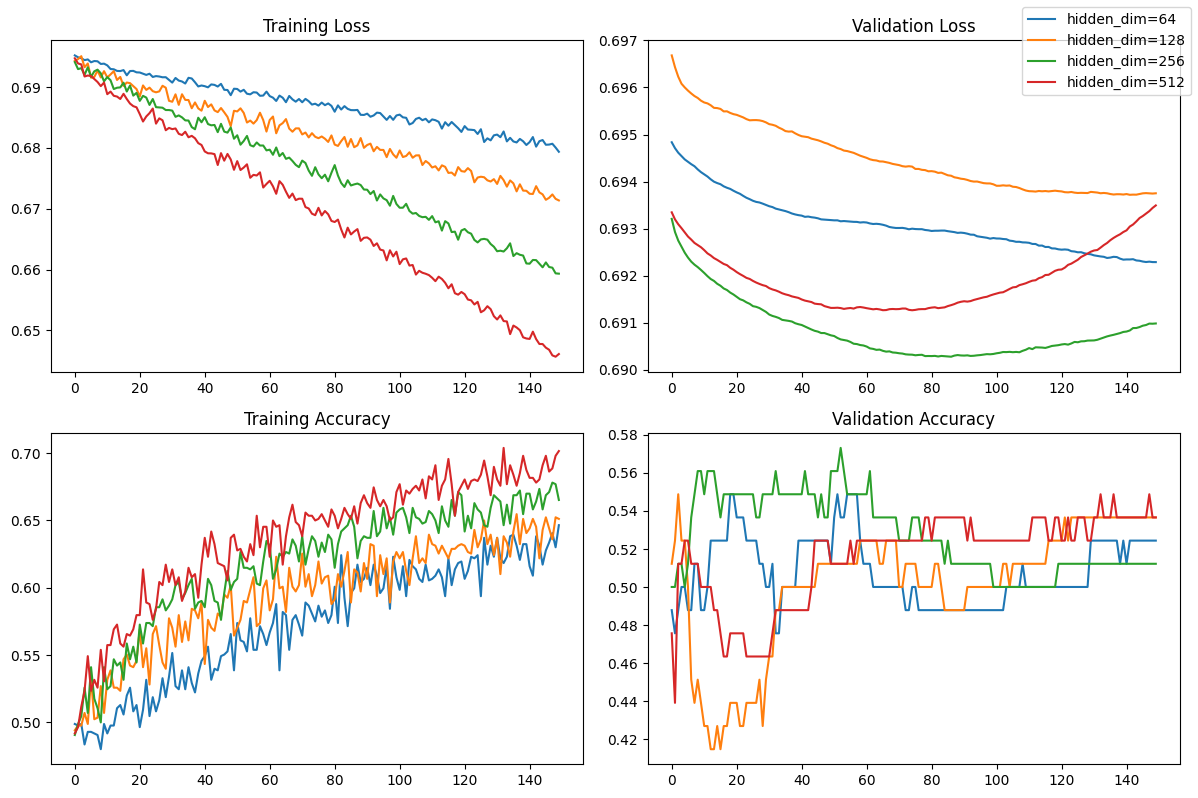

In [145]:
# hyperparameter study: mlp hidden_dim

predicate = "behind"
batch_size = 16
total_steps = 8_000

data_file_path = f"{DATA_DIRECTORY}/predicate_probe_data/{predicate}"
train_ds = PredicateProbeDataset(data_file_path + "_train.pt")
train_dl = DataLoader(train_ds, batch_size=batch_size) 
val_ds = PredicateProbeDataset(data_file_path + "_valid.pt")
val_dl = DataLoader(val_ds, batch_size=batch_size) 

num_epochs = total_steps // (len(train_ds) // batch_size)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax[0,0].set_title("Training Loss")
ax[0,1].set_title("Training Accuracy")
ax[1,0].set_title("Validation Loss")
ax[1,1].set_title("Validation Accuracy")

for hidden_dim in (64, 128, 256, 512):
    mlp_model = MLP(hidden_dim=hidden_dim)

    train_outputs = train(mlp_model, train_dl, val_dl, 
                        num_epochs=num_epochs, lr=1e-5, verbose=False)
    train_losses, val_losses, train_confusion_matrices, val_confusion_matrices = train_outputs

    # torch.save(mlp_model.state_dict(), f"{MODEL_DIRECTORY}/test.pt")

    # basic plotting
    ax[0,0].plot(train_losses, label=f"{hidden_dim=}")
    ax[1,0].plot(val_losses)
    train_accs = [compute_cm_metrics(cm)["accuracy"] for cm in train_confusion_matrices]
    val_accs = [compute_cm_metrics(cm)["accuracy"] for cm in val_confusion_matrices]
    ax[0,1].plot(train_accs)
    ax[1,1].plot(val_accs)

fig.legend()
fig.tight_layout()
fig.show()

C:\Users\vince\AppData\Local\Temp\ipykernel_50092\2382275466.py:52: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


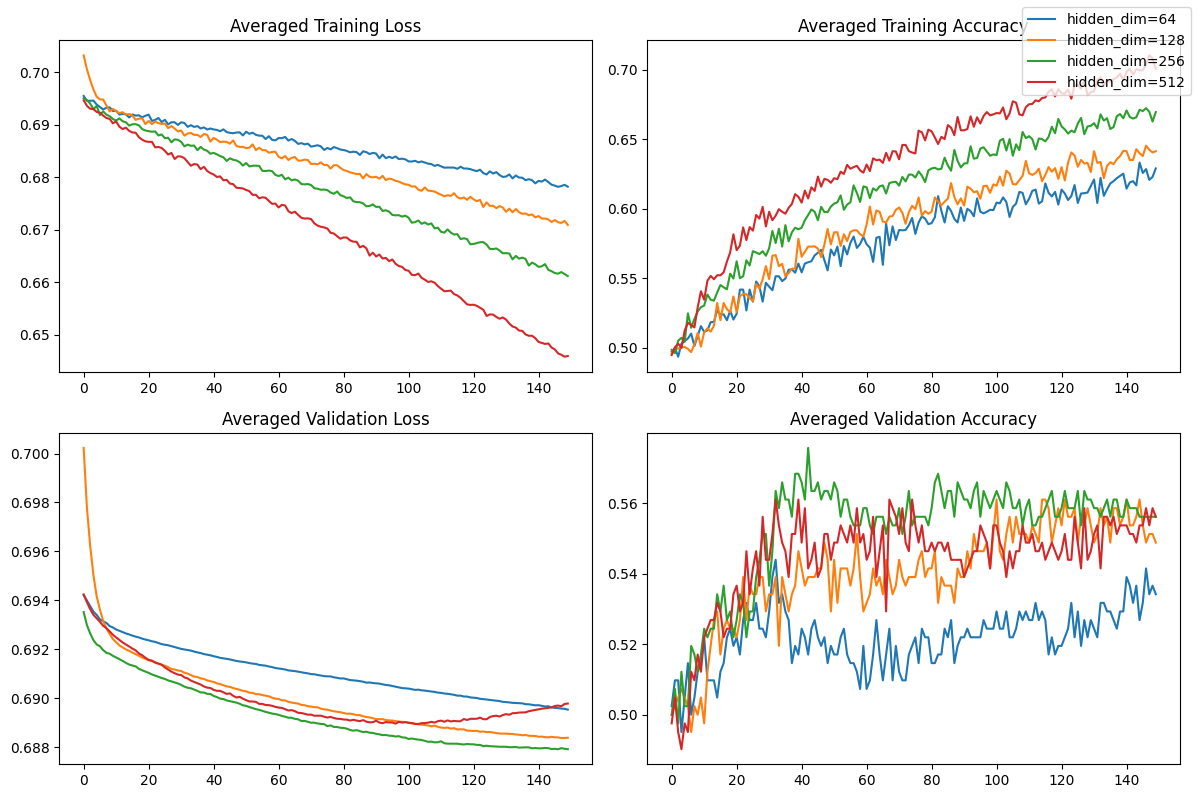

In [227]:
# hyperparameter study: mlp hidden_dim

predicate = "behind"
batch_size = 16
total_steps = 8_000

data_file_path = f"{DATA_DIRECTORY}/predicate_probe_data/{predicate}"
train_ds = PredicateProbeDataset(data_file_path + "_train.pt")
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True) 
val_ds = PredicateProbeDataset(data_file_path + "_valid.pt")
val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=True) 

num_epochs = total_steps // (len(train_ds) // batch_size)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax[0,0].set_title("Averaged Training Loss")
ax[0,1].set_title("Averaged Training Accuracy")
ax[1,0].set_title("Averaged Validation Loss")
ax[1,1].set_title("Averaged Validation Accuracy")

all_metrics = defaultdict(lambda: defaultdict(list))

for _ in range(5):
    for hidden_dim in (64, 128, 256, 512):
        mlp_model = MLP(hidden_dim=hidden_dim)

        train_outputs = train(mlp_model, train_dl, val_dl, 
                            num_epochs=num_epochs, lr=1e-5, verbose=False)
        train_losses, val_losses, train_confusion_matrices, val_confusion_matrices = train_outputs
        all_metrics[hidden_dim]["all_train_losses"].append(train_losses)
        all_metrics[hidden_dim]["all_val_losses"].append(val_losses)

        # torch.save(mlp_model.state_dict(), f"{MODEL_DIRECTORY}/test.pt")

        train_accs = [compute_cm_metrics(cm)["accuracy"] for cm in train_confusion_matrices]
        val_accs = [compute_cm_metrics(cm)["accuracy"] for cm in val_confusion_matrices]
        all_metrics[hidden_dim]["all_train_accs"].append(train_accs)
        all_metrics[hidden_dim]["all_val_accs"].append(val_accs)

for hidden_dim in all_metrics:
    all_train_losses = all_metrics[hidden_dim]["all_train_losses"]
    all_val_losses = all_metrics[hidden_dim]["all_val_losses"]
    all_train_accs = all_metrics[hidden_dim]["all_train_accs"]
    all_val_accs = all_metrics[hidden_dim]["all_val_accs"]
    ax[0,0].plot(np.mean(all_train_losses, axis=0), label=f"{hidden_dim=}")
    ax[0,1].plot(np.mean(all_train_accs, axis=0))
    ax[1,0].plot(np.mean(all_val_losses, axis=0))
    ax[1,1].plot(np.mean(all_val_accs, axis=0))

fig.legend()
fig.tight_layout()
fig.show()

In [178]:
# training all predicates
batch_size = 16
total_steps = 8_000
hidden_dim = 128
num_trials = 5

for predicate in ["behind"]:
    data_file_path = f"{DATA_DIRECTORY}/predicate_probe_data/{predicate}"
    train_ds = PredicateProbeDataset(data_file_path + "_train.pt")
    val_ds = PredicateProbeDataset(data_file_path + "_valid.pt")

    num_epochs = total_steps // (len(train_ds) // batch_size)

    best_val_acc = 0.0
    all_metrics = defaultdict(list)
    """
    all_metrics has the following keys:
        all_train_losses: num_trials lists of per-epoch training losses
        all_val_losses: num_trials lists of per-epoch val losses
        all_train_confusion_matrices: num_trials lists of per-epoch train cms
        all_val_confusion_matrices: num_trials lists of per-epoch val cms
    """

    for _ in range(num_trials):
        mlp_model = MLP(hidden_dim=hidden_dim)
        train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True) 
        val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=True) 

        train_outputs = train(mlp_model, train_dl, val_dl, 
                            num_epochs=num_epochs, lr=1e-5, verbose=False)
        train_losses, val_losses, train_confusion_matrices, val_confusion_matrices = train_outputs
        all_metrics["all_train_losses"].append(train_losses)
        all_metrics["all_val_losses"].append(val_losses)
        all_metrics["all_train_confusion_matrices"].append(train_confusion_matrices)
        all_metrics["all_val_confusion_matrices"].append(val_confusion_matrices)

        last_val_acc = compute_cm_metrics(val_confusion_matrices[-1])["accuracy"]
        # save best model, based on validation accuracy
        if last_val_acc > best_val_acc:
            best_val_acc = last_val_acc
            torch.save(mlp_model.state_dict(), f"{MODEL_DIRECTORY}/mlp_{predicate}.pt")

    # save training metrics
    torch.save(all_metrics, f"{OUTPUT_DIRECTORY}/trainval_metrics_{predicate}.pt")

### depth emb

C:\Users\vince\AppData\Local\Temp\ipykernel_50092\3038696534.py:53: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


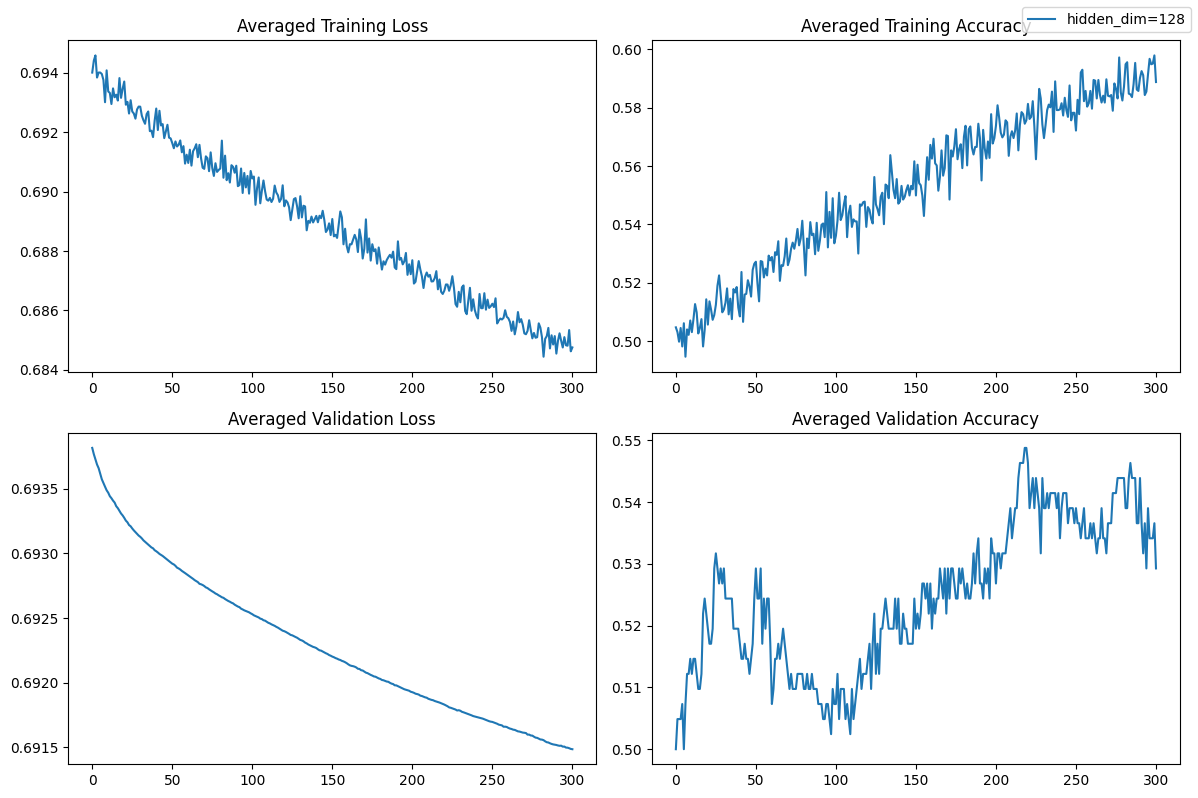

In [326]:
# hyperparameter study: mlp hidden_dim

predicate = "behind"
batch_size = 16
total_steps = 16_000

data_file_path = f"{DATA_DIRECTORY}/predicate_probe_data/{predicate}"
train_ds = PredicateProbeDataset(data_file_path + "_train.pt")
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True) 
val_ds = PredicateProbeDataset(data_file_path + "_valid.pt")
val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=True) 

num_epochs = total_steps // (len(train_ds) // batch_size)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax[0,0].set_title("Averaged Training Loss")
ax[0,1].set_title("Averaged Training Accuracy")
ax[1,0].set_title("Averaged Validation Loss")
ax[1,1].set_title("Averaged Validation Accuracy")

all_metrics = defaultdict(lambda: defaultdict(list))

for _ in range(5):
    # for hidden_dim in (64, 128, 256, 512):
    for hidden_dim in (128,):
        mlp_model = MLP(input_dim=1024, hidden_dim=hidden_dim) # double input_dim

        train_outputs = train(mlp_model, train_dl, val_dl, embedding_type="image+depth",
                            num_epochs=num_epochs, lr=1e-6, verbose=False)
        train_losses, val_losses, train_confusion_matrices, val_confusion_matrices = train_outputs
        all_metrics[hidden_dim]["all_train_losses"].append(train_losses)
        all_metrics[hidden_dim]["all_val_losses"].append(val_losses)

        # torch.save(mlp_model.state_dict(), f"{MODEL_DIRECTORY}/test.pt")

        train_accs = [compute_cm_metrics(cm)["accuracy"] for cm in train_confusion_matrices]
        val_accs = [compute_cm_metrics(cm)["accuracy"] for cm in val_confusion_matrices]
        all_metrics[hidden_dim]["all_train_accs"].append(train_accs)
        all_metrics[hidden_dim]["all_val_accs"].append(val_accs)

for hidden_dim in all_metrics:
    all_train_losses = all_metrics[hidden_dim]["all_train_losses"]
    all_val_losses = all_metrics[hidden_dim]["all_val_losses"]
    all_train_accs = all_metrics[hidden_dim]["all_train_accs"]
    all_val_accs = all_metrics[hidden_dim]["all_val_accs"]
    ax[0,0].plot(np.mean(all_train_losses, axis=0), label=f"{hidden_dim=}")
    ax[0,1].plot(np.mean(all_train_accs, axis=0))
    ax[1,0].plot(np.mean(all_val_losses, axis=0))
    ax[1,1].plot(np.mean(all_val_accs, axis=0))

fig.legend()
fig.tight_layout()
fig.show()

## evaluation

### image emb only

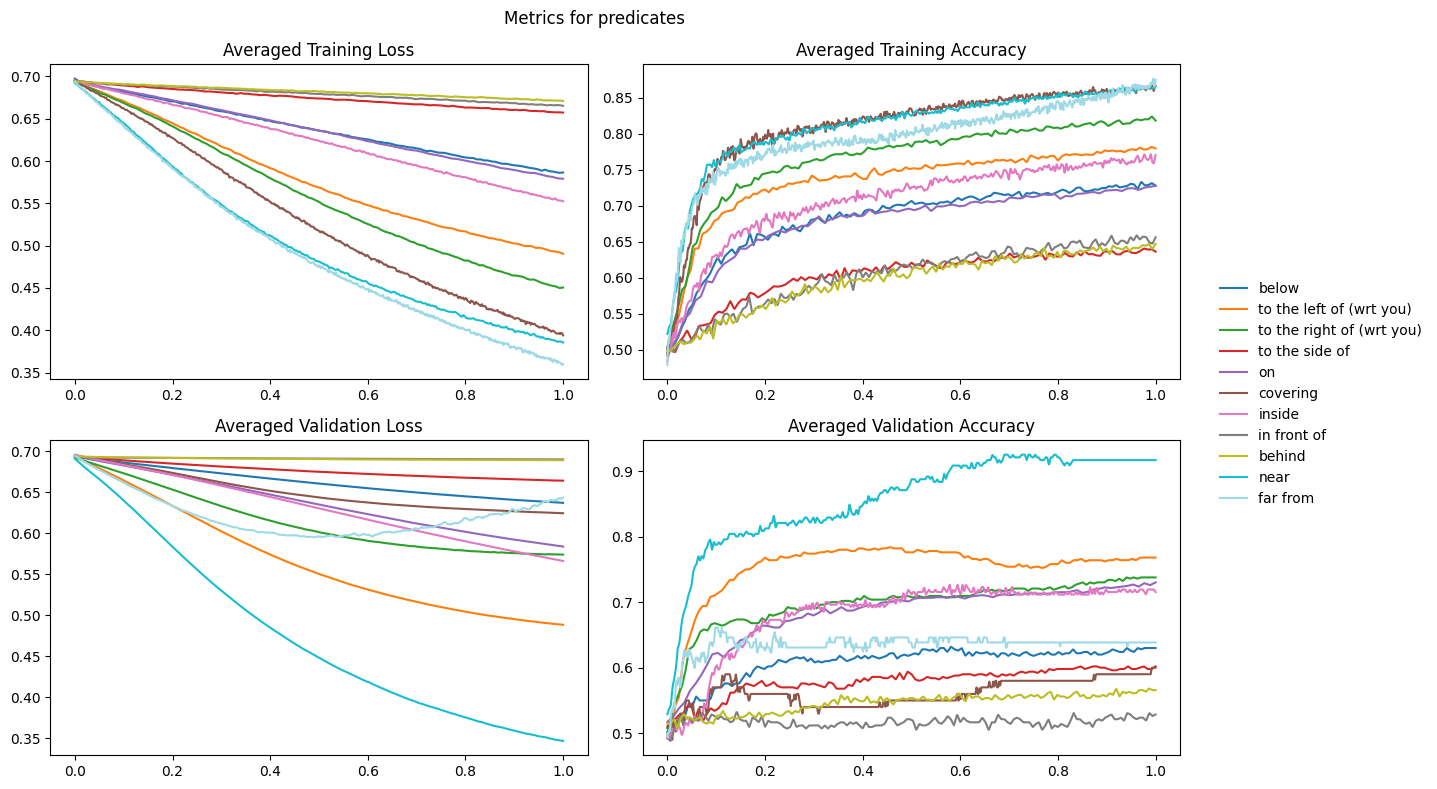

In [236]:
plot_metrics(allowed_predicates)

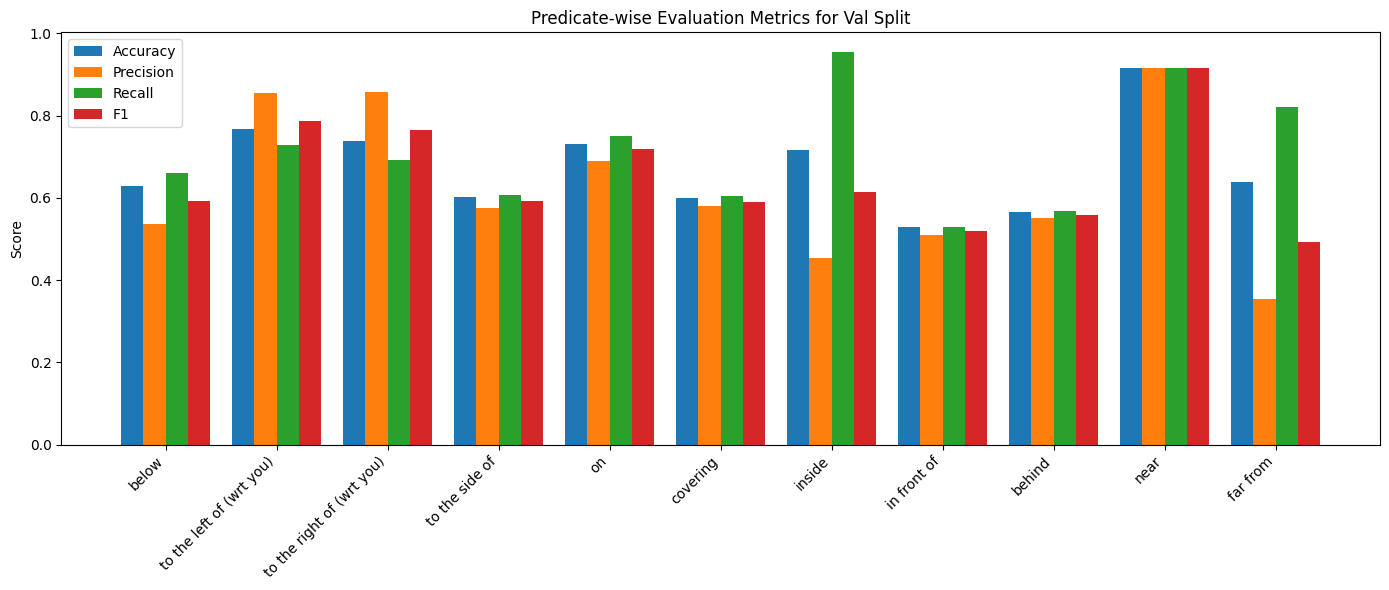

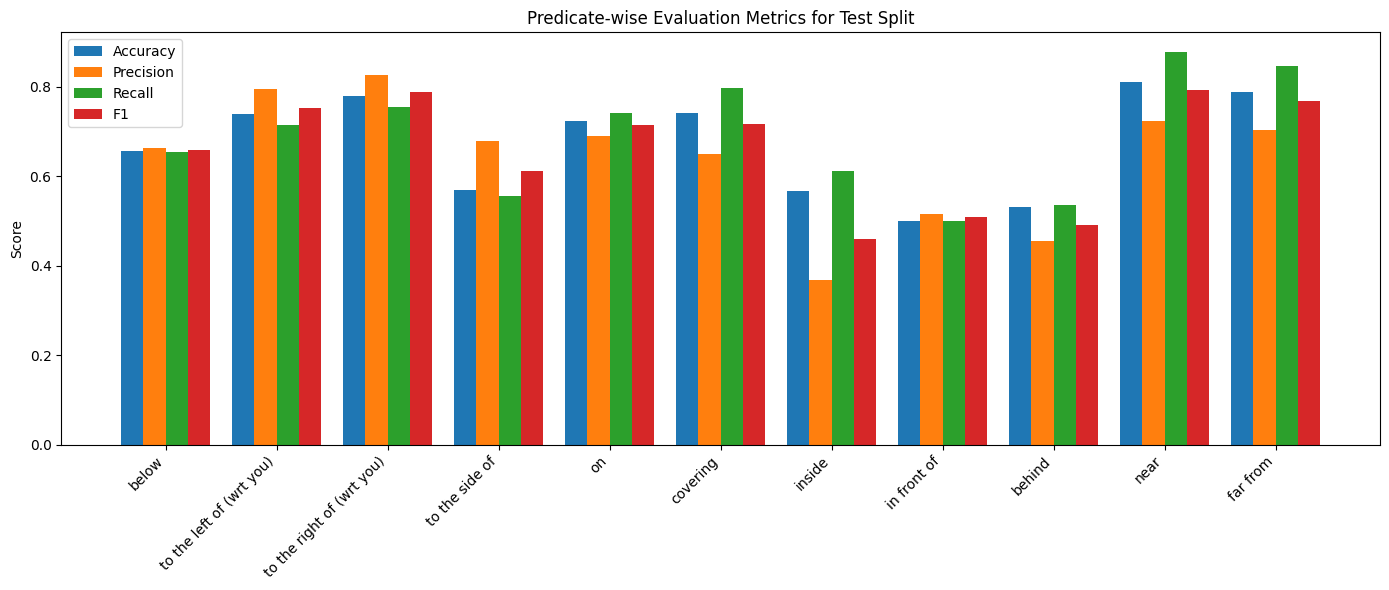

In [261]:
# bar plots for final (or best?) accuracy for each predicate 
plot_bar_clf_metrics(allowed_predicates, "val")
plot_bar_clf_metrics(allowed_predicates, "test")

<Axes: >

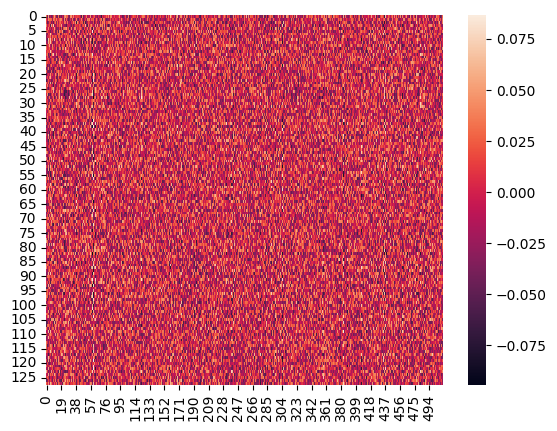

In [268]:
import seaborn as sns
import matplotlib.pyplot as plt

predicate = "near"

mlp_model = MLP()
mlp_model.load_state_dict(torch.load(f"{MODEL_DIRECTORY}/mlp_{predicate}.pt"))
sns.heatmap(mlp_model.net[0].weight.cpu().detach().numpy())

#### inside analysis

In [393]:
# "inside" analysis
test_dataset_args = default_dataset_args | {"split": "test"}
test_dataloader, test_predicates, test_objects = create_dataloader(
    **test_dataset_args,
    num_workers=1,
    batch_size=1,
)

inside_samples = []

for batch in test_dataloader:
    if batch["predicate"]["name"][0] == "inside":
        inside_samples.append(batch)

4744 relations in test
Percentage of positive labels  in test: 0.5
Percentage of negative labels  in test: 0.5
{'points away': (63, 63, 0.5), 'to the right of': (60, 60, 0.5), 'around': (82, 82, 0.5), 'to the side of': (174, 174, 0.5), 'to the left of (wrt you)': (126, 126, 0.5), 'touching': (66, 66, 0.5), 'to the left of': (30, 30, 0.5), 'under': (47, 47, 0.5), 'passing through': (53, 53, 0.5), 'inside': (60, 60, 0.5), 'faces away': (77, 77, 0.5), 'far from': (47, 47, 0.5), 'faces towards': (60, 60, 0.5), 'to the side of (wrt you)': (36, 36, 0.5), 'behind': (33, 33, 0.5), 'aligned to': (58, 58, 0.5), 'on top of': (74, 74, 0.5), 'on': (116, 116, 0.5), 'covering': (157, 157, 0.5), 'in front of (wrt you)': (36, 36, 0.5), 'in front of': (64, 64, 0.5), 'leaning against': (37, 37, 0.5), 'near': (119, 119, 0.5), 'points towards': (69, 69, 0.5), 'below': (74, 74, 0.5), 'behind (wrt you)': (64, 64, 0.5), 'to the right of (wrt you)': (115, 115, 0.5), 'in': (145, 145, 0.5), 'over': (218, 218, 0.

In [276]:
inside_samples[0]

{'subject': {'name': ['Cell Phone'],
  'idx': tensor([17]),
  'bbox': tensor([[0.0000, 0.8795, 0.2232, 0.5000]]),
  't': tensor([[-0.4600,  0.2262,  0.2469, -1.2873]])},
 'object': {'name': ['Tire'],
  'idx': tensor([63]),
  'bbox': tensor([[0.3125, 0.9955, 0.0000, 0.9955]]),
  't': tensor([[ 0.3594, -0.8197, -0.2469,  1.2873]])},
 'predicate': {'name': ['inside'],
  'idx': tensor([7]),
  'bbox': tensor([[0.0000, 0.9955, 0.0000, 0.9955]])},
 'label': tensor([True]),
 'rgb_source': ['./data/20200223/inside - Cell Phone_6fd3968f737bcf7e64ac3b2f693d10e5 - Tire_tire_2 - initialState cam0 rgb.png'],
 'weight': tensor([0.9184], dtype=torch.float64),
 'img_crop': tensor([[[[0.6824, 0.6824, 0.6824,  ..., 0.6706, 0.6706, 0.6745],
           [0.6824, 0.6784, 0.6824,  ..., 0.6706, 0.6706, 0.6745],
           [0.6824, 0.6784, 0.6824,  ..., 0.6706, 0.6706, 0.6745],
           ...,
           [0.7176, 0.7137, 0.7098,  ..., 0.6980, 0.7020, 0.7020],
           [0.7216, 0.7176, 0.7137,  ..., 0.6980, 0.

In [394]:
clip_model = CLIPModel.from_pretrained(CLIP_MODEL_NAME).to(device)
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
clip_model.eval()

tn_list, fp_list, fn_list, tp_list = [], [], [], []

mlp_model = MLP().to(device)
mlp_model.load_state_dict(torch.load("models/mlp_inside.pt"))

for sample in inside_samples:
    image_inputs = clip_processor(images=sample["img_crop"], return_tensors="pt", do_rescale=False).to(device)

    with torch.no_grad():
        image_embs = clip_model.get_image_features(**image_inputs).to(device)

    y = sample["label"].float().to(device)
    logits = mlp_model(image_embs)
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).long()

    if preds[0] == 1:
        if y[0] == 1 and len(tp_list) < 10:
            tp_list.append(sample)
        if y[0] == 0 and len(fp_list) < 10:
            fp_list.append(sample)

    elif preds[0] == 0:
        if y[0] == 1 and len(fn_list) < 10:
            fn_list.append(sample)
        if y[0] == 0 and len(tn_list) < 10:
            tn_list.append(sample)
    if all(len(l) >= 10 for l in (tn_list, fp_list, fn_list, tp_list)):
        break
    

Text(0.5, 1.0, 'Sample Depth Map of RGB Image')

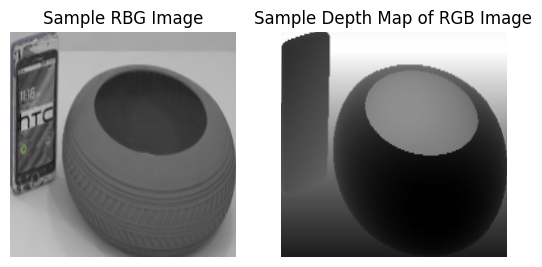

In [411]:
i = 1

fig, ax = plt.subplots(1,2)
ax[0].imshow(np.transpose(tn_list[i]["img_crop"][0], (1,2,0)))
ax[0].axis("off")
ax[0].set_title("Sample RBG Image")
ax[1].imshow(np.transpose(tn_list[i]["depth_crop"][0], (1,2,0)), cmap="gray")
ax[1].axis("off")
ax[1].set_title("Sample Depth Map of RGB Image")

C:\Users\vince\AppData\Local\Temp\ipykernel_50092\3464700245.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


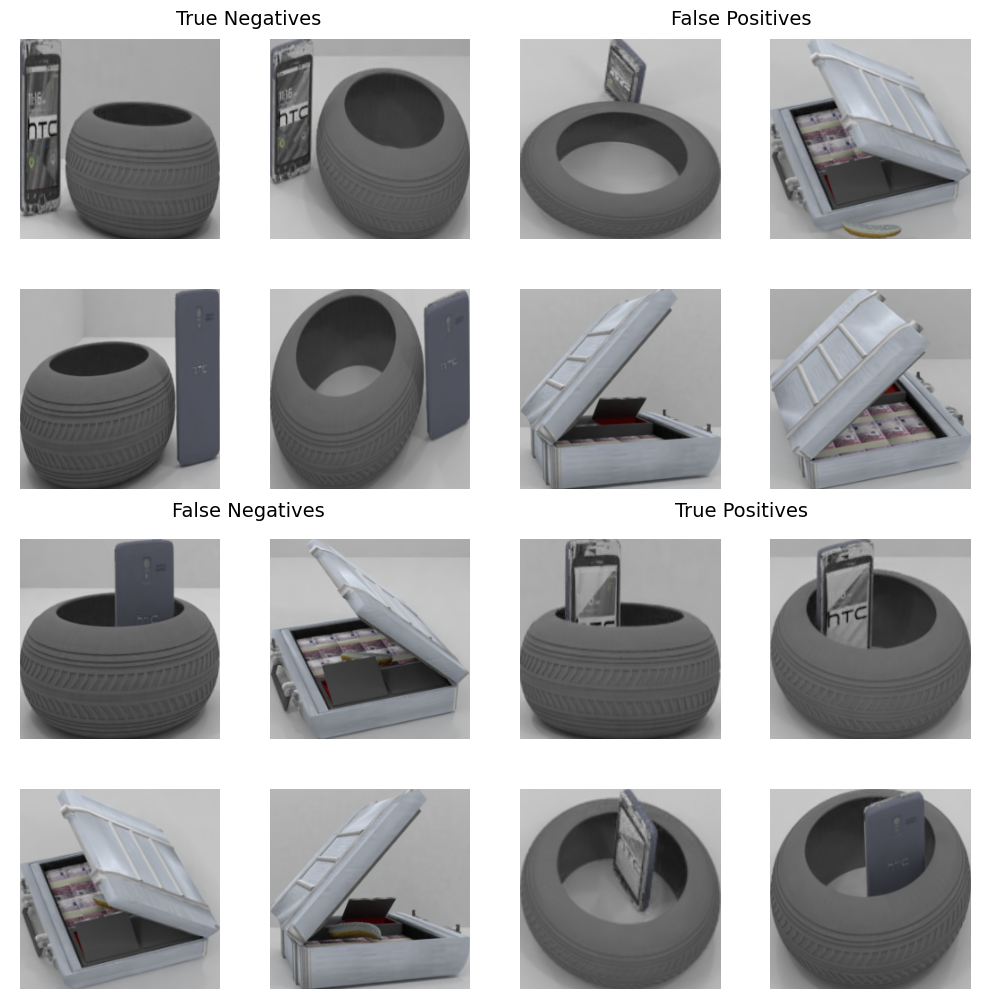

In [ ]:
def plot_tf_grid_2x2(images_dict):
    """
    images_dict: dict with keys 'TP', 'FP', 'FN', 'TN'
                 each value is a list of 4 image tensors in CHW format (C×H×W)
    """
    categories = ["TN", "FP", "FN", "TP"]
    titles = {
        "TN": "True Negatives",
        "FP": "False Positives",
        "FN": "False Negatives",
        "TP": "True Positives"
    }

    fig, axs = plt.subplots(2, 2, figsize=(10, 10))

    for idx, cat in enumerate(categories):
        row, col = divmod(idx, 2)
        ax = axs[row, col]

        # Turn off the main subplot axis
        ax.axis("off")
        ax.set_title(titles[cat], fontsize=14)

        # Coordinates for nested 2x2 grid within the subplot
        for i, img in enumerate(images_dict[cat]):
            sub_row, sub_col = divmod(i, 2)
            left = col * 0.5 + sub_col * 0.25 + 0.025
            # Add vertical offset to give room for title (e.g., 0.04 units)
            top_margin = 0.03
            bottom = 1 - (row * 0.5 + (sub_row + 1) * 0.25 + 0.025) + top_margin

            ax_img = fig.add_axes([left, bottom, 0.2, 0.2])
            img_np = np.transpose(img, (1, 2, 0))  # CHW → HWC
            ax_img.imshow(img_np)
            ax_img.axis("off")

    plt.tight_layout()
    plt.show()



tf_dict = {}

images = [sample["img_crop"][0] for sample in tn_list[:4]]
tf_dict["TN"] = images
images = [sample["img_crop"][0] for sample in fp_list[:4]]
tf_dict["FP"] = images
images = [sample["img_crop"][0] for sample in fn_list[:4]]
tf_dict["FN"] = images
images = [sample["img_crop"][0] for sample in tp_list[:4]]
tf_dict["TP"] = images

plot_tf_grid_2x2(tf_dict)

#### far from analysis

In [368]:
# "far from" analysis
test_dataset_args = default_dataset_args | {"split": "test"}
test_dataloader, test_predicates, test_objects = create_dataloader(
    **test_dataset_args,
    num_workers=1,
    batch_size=1,
)

far_from_samples = []

for batch in test_dataloader:
    if batch["predicate"]["name"][0] == "far from":
        far_from_samples.append(batch)

4744 relations in test
Percentage of positive labels  in test: 0.5
Percentage of negative labels  in test: 0.5
{'points away': (63, 63, 0.5), 'to the right of': (60, 60, 0.5), 'around': (82, 82, 0.5), 'to the side of': (174, 174, 0.5), 'to the left of (wrt you)': (126, 126, 0.5), 'touching': (66, 66, 0.5), 'to the left of': (30, 30, 0.5), 'under': (47, 47, 0.5), 'passing through': (53, 53, 0.5), 'inside': (60, 60, 0.5), 'faces away': (77, 77, 0.5), 'far from': (47, 47, 0.5), 'faces towards': (60, 60, 0.5), 'to the side of (wrt you)': (36, 36, 0.5), 'behind': (33, 33, 0.5), 'aligned to': (58, 58, 0.5), 'on top of': (74, 74, 0.5), 'on': (116, 116, 0.5), 'covering': (157, 157, 0.5), 'in front of (wrt you)': (36, 36, 0.5), 'in front of': (64, 64, 0.5), 'leaning against': (37, 37, 0.5), 'near': (119, 119, 0.5), 'points towards': (69, 69, 0.5), 'below': (74, 74, 0.5), 'behind (wrt you)': (64, 64, 0.5), 'to the right of (wrt you)': (115, 115, 0.5), 'in': (145, 145, 0.5), 'over': (218, 218, 0.

In [369]:
clip_model = CLIPModel.from_pretrained(CLIP_MODEL_NAME).to(device)
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
clip_model.eval()

tn_list, fp_list, fn_list, tp_list = [], [], [], []

mlp_model = MLP().to(device)
mlp_model.load_state_dict(torch.load("models/mlp_far from.pt"))

for sample in far_from_samples:
    image_inputs = clip_processor(images=sample["img_crop"], return_tensors="pt", do_rescale=False).to(device)

    with torch.no_grad():
        image_embs = clip_model.get_image_features(**image_inputs).to(device)

    y = sample["label"].float().to(device)
    logits = mlp_model(image_embs)
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).long()

    if preds[0] == 1:
        if y[0] == 1 and len(tp_list) < 10:
            tp_list.append(sample)
        if y[0] == 0 and len(fp_list) < 10:
            fp_list.append(sample)

    elif preds[0] == 0:
        if y[0] == 1 and len(fn_list) < 10:
            fn_list.append(sample)
        if y[0] == 0 and len(tn_list) < 10:
            tn_list.append(sample)
    if all(len(l) >= 10 for l in (tn_list, fp_list, fn_list, tp_list)):
        break
    

C:\Users\vince\AppData\Local\Temp\ipykernel_50092\880918441.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


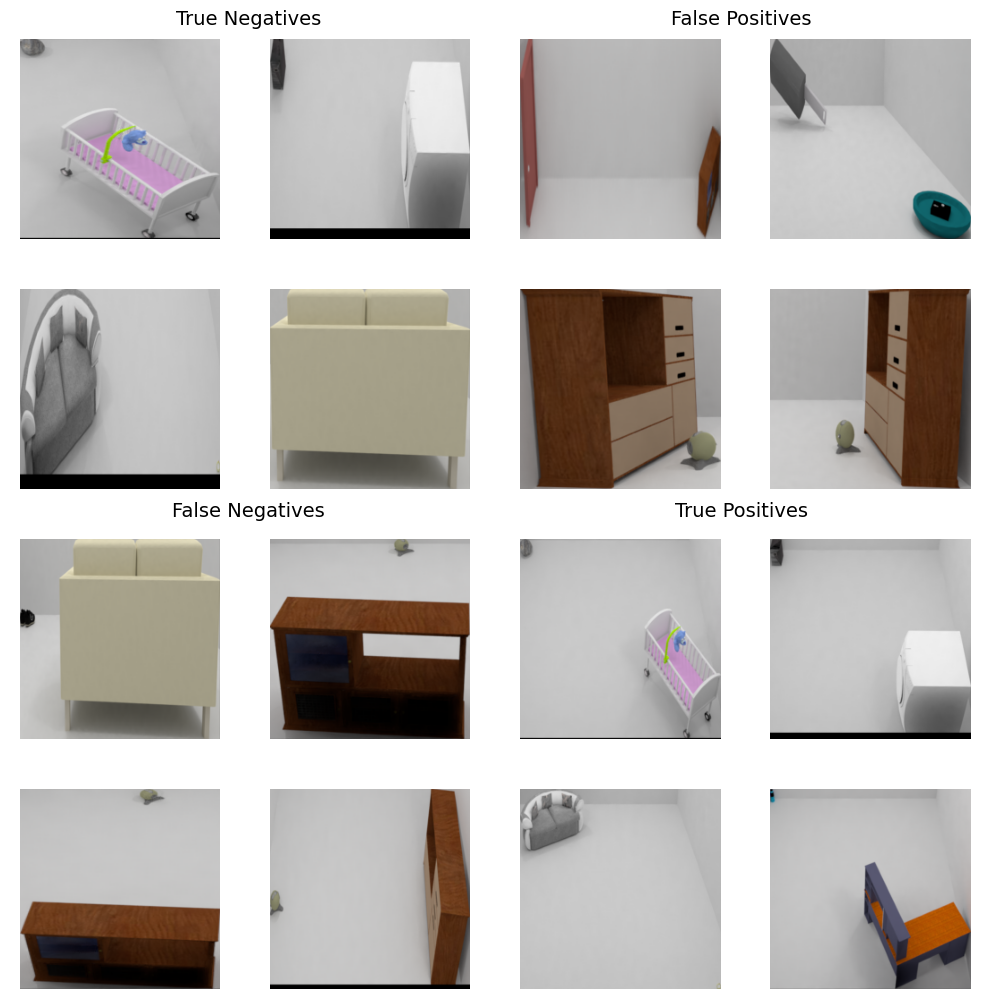

In [370]:
def plot_tf_grid_2x2(images_dict):
    """
    images_dict: dict with keys 'TP', 'FP', 'FN', 'TN'
                 each value is a list of 4 image tensors in CHW format (C×H×W)
    """
    categories = ["TN", "FP", "FN", "TP"]
    titles = {
        "TN": "True Negatives",
        "FP": "False Positives",
        "FN": "False Negatives",
        "TP": "True Positives"
    }

    fig, axs = plt.subplots(2, 2, figsize=(10, 10))

    for idx, cat in enumerate(categories):
        row, col = divmod(idx, 2)
        ax = axs[row, col]

        # Turn off the main subplot axis
        ax.axis("off")
        ax.set_title(titles[cat], fontsize=14)

        # Coordinates for nested 2x2 grid within the subplot
        for i, img in enumerate(images_dict[cat]):
            sub_row, sub_col = divmod(i, 2)
            left = col * 0.5 + sub_col * 0.25 + 0.025
            # Add vertical offset to give room for title (e.g., 0.04 units)
            top_margin = 0.03
            bottom = 1 - (row * 0.5 + (sub_row + 1) * 0.25 + 0.025) + top_margin

            ax_img = fig.add_axes([left, bottom, 0.2, 0.2])
            img_np = np.transpose(img, (1, 2, 0))  # CHW → HWC
            ax_img.imshow(img_np)
            ax_img.axis("off")

    plt.tight_layout()
    plt.show()



tf_dict = {}

images = [sample["img_crop"][0] for sample in tn_list[:4]]
tf_dict["TN"] = images
images = [sample["img_crop"][0] for sample in fp_list[:4]]
tf_dict["FP"] = images
images = [sample["img_crop"][0] for sample in fn_list[:4]]
tf_dict["FN"] = images
images = [sample["img_crop"][0] for sample in tp_list[:4]]
tf_dict["TP"] = images

plot_tf_grid_2x2(tf_dict)

### depth emb

<string>:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


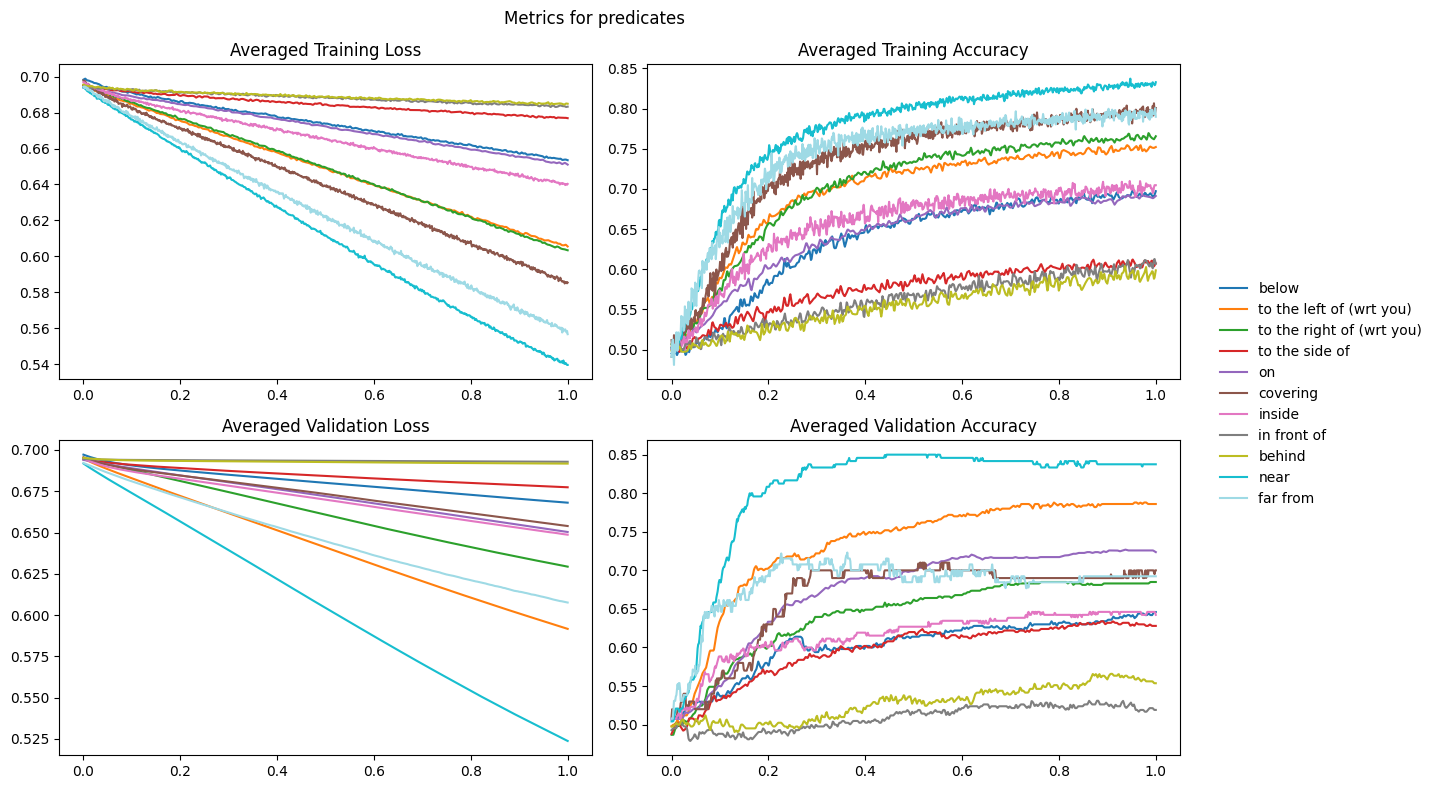

In [331]:
plot_metrics(allowed_predicates, embedding_type="image+depth")

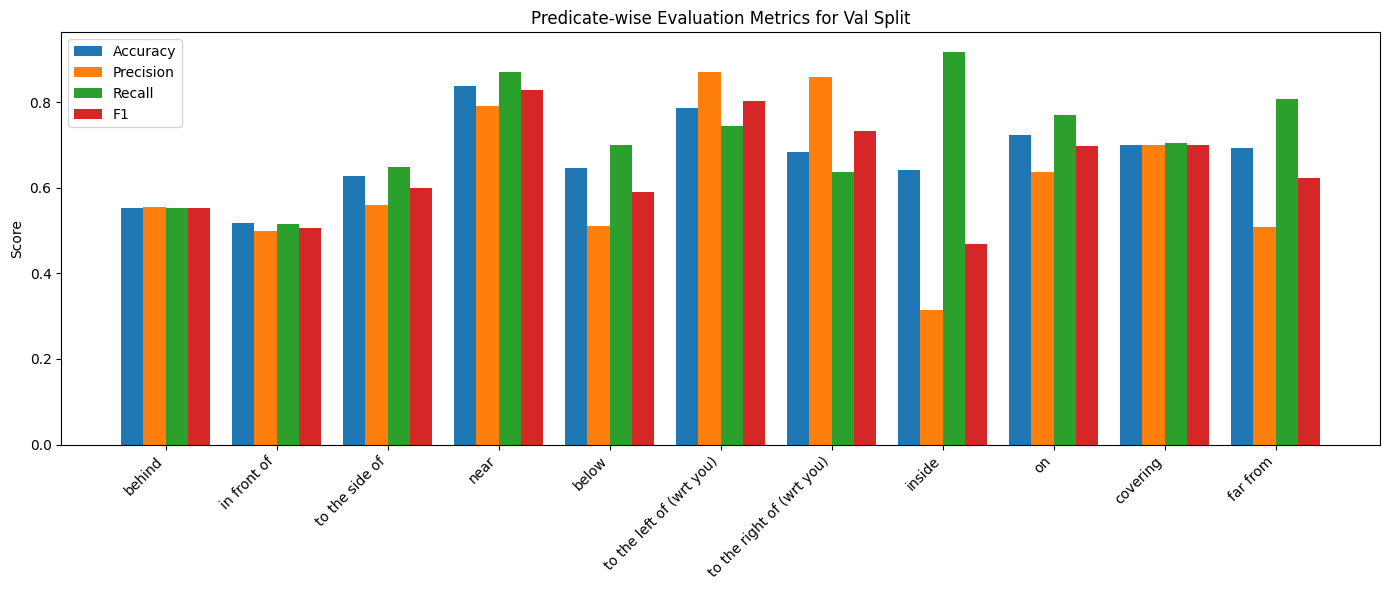

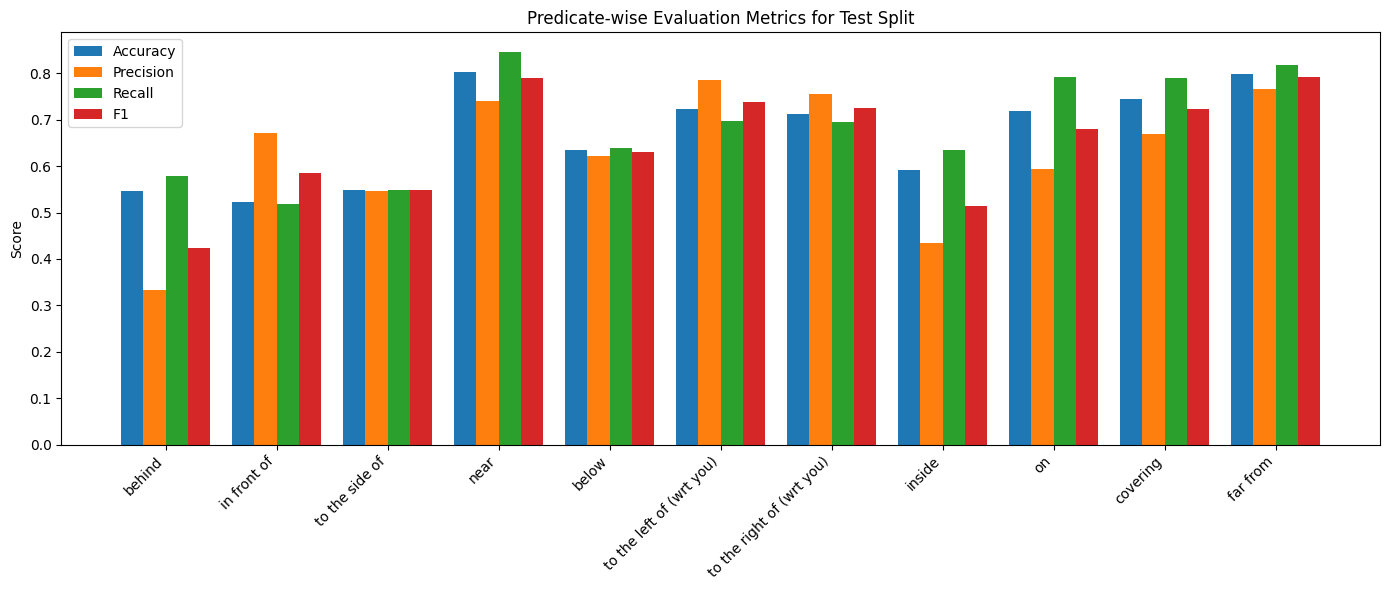

In [335]:
plot_bar_clf_metrics(allowed_predicates, "val", embedding_type="image+depth")
plot_bar_clf_metrics(allowed_predicates, "test", embedding_type="image+depth")

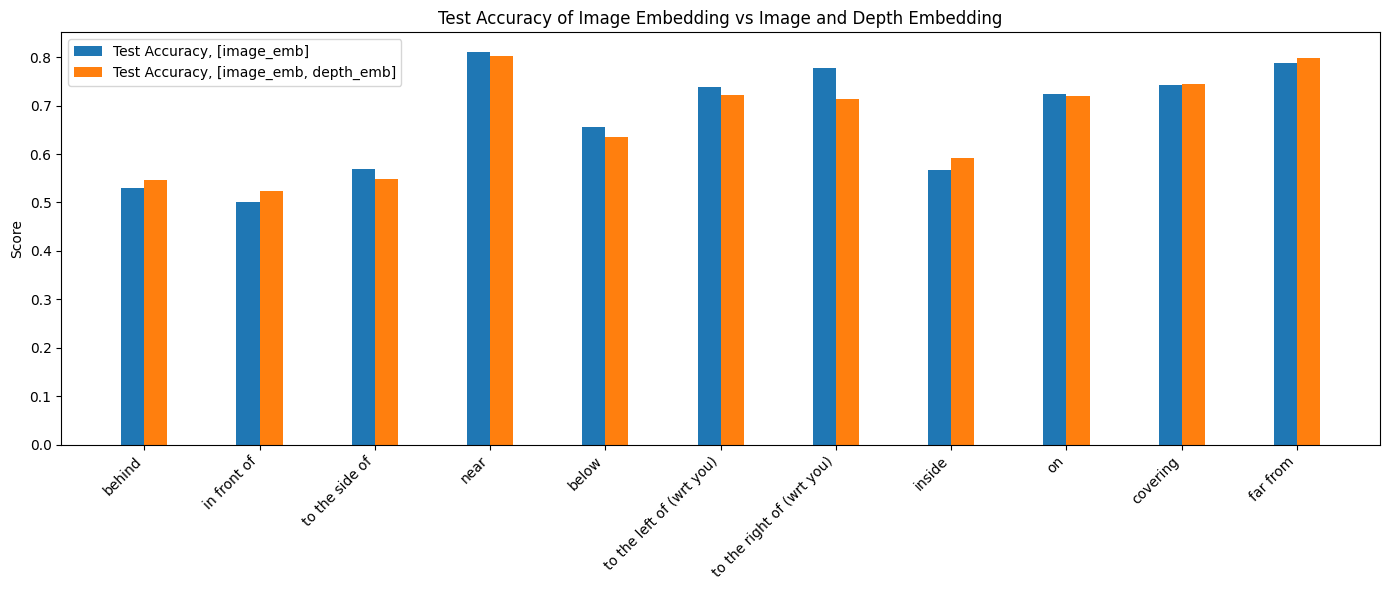

In [341]:
image_test_metrics = get_test_metrics(allowed_predicates, embedding_type="image")
depth_test_metrics = get_test_metrics(allowed_predicates, embedding_type="image+depth")

metric_labels = ["Test Accuracy, [image_emb]", "Test Accuracy, [image_emb, depth_emb]"]
num_predicates = len(allowed_predicates)
num_metrics = len(metric_labels)

metrics_array = np.array(
    [[image_test_metrics[predicate]["accuracy"], depth_test_metrics[predicate]["accuracy"]]
        for predicate in allowed_predicates]
)

# Bar settings
x = np.arange(num_predicates)
bar_width = 0.2
offsets = np.arange(num_metrics) * bar_width

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

for i in range(num_metrics):
    ax.bar(x + offsets[i], metrics_array[:, i], width=bar_width, label=metric_labels[i])

# Ticks and labels
ax.set_xticks(x + bar_width * (num_metrics - 1) / 2)
ax.set_xticklabels(allowed_predicates, rotation=45, ha="right")
ax.set_ylabel("Score")
ax.set_title(f"Test Accuracy of Image Embedding vs Image and Depth Embedding")
ax.legend()
plt.tight_layout()
plt.show()

In [349]:
samples = torch.load("data/predicate_probe_data/behind_train.pt")
image_emb, depth_emb = samples[0]["image_emb"], samples[0]["depth_emb"]

In [ ]:
torch.nn.functional.cosine_similarity(image_emb.unsqueeze(0), depth_emb.unsqueeze(0))

tensor([0.8453], device='cuda:0')

In [357]:
for predicate in allowed_predicates:
    all_sims = []
    for split in ("train", "valid", "test"):
        samples = torch.load(f"{DATA_DIRECTORY}/predicate_probe_data/{predicate}_{split}.pt")
        for sample in samples:
            image_emb, depth_emb = sample["image_emb"], sample["depth_emb"]
            all_sims.append(
                torch.nn.functional.cosine_similarity(image_emb.unsqueeze(0), depth_emb.unsqueeze(0)).cpu().numpy()
            )
    print(f"{predicate}: {np.mean(all_sims):.4f}")
        

below: 0.8051
to the left of (wrt you): 0.7893
to the right of (wrt you): 0.7900
to the side of: 0.8006
on: 0.8006
covering: 0.7832
inside: 0.8112
in front of: 0.8041
behind: 0.7996
near: 0.8149
far from: 0.8333


## attention maps

* use vision model outputs to access attention maps (`outputs["vision_model_output"]`)
* outputs keys: `odict_keys(['logits_per_image', 'logits_per_text', 'text_embeds', 'image_embeds', 'text_model_output', 'vision_model_output'])`

1. for each predicate, analyze attention maps of a few examples
1. try to draw some comparisons/conclusions among samples of the same predicate
1. try to draw some comparisons/conclusions between samples of different predicates 
1. do insights from attention map analysis correspond to binary classifier performance at all?
1. is the `bbox_mask` associated with each sample helpful in attention mask analysis? for masking irrelevant areas of the image/attention maps? 

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from transformers import CLIPProcessor, CLIPModel
from PIL import Image

# Load model and processor
model = CLIPModel.from_pretrained(CLIP_MODEL_NAME, output_attentions=True)
processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
model.eval()

# Load and process image
image = Image.open("data/apple.jpg").convert("RGB")
inputs = processor(images=image, return_tensors="pt")

# Run model with attention outputs
with torch.no_grad():
    outputs = model.vision_model(
        pixel_values=inputs["pixel_values"],
        output_attentions=True,
        output_hidden_states=False,
        return_dict=True
    )

# Extract attention from a specific layer and head
attn = outputs.attentions  # List of attention matrices per layer

layer_idx = -1     # last layer
head_idx = 0       # first head

# attn[layer]: shape = (1, num_heads, num_tokens, num_tokens)
attn_map = attn[layer_idx][0, head_idx]  # shape: (num_tokens, num_tokens)

# Get attention from [CLS] token to image patches
cls_attn = attn_map[0, 1:]  # skip [CLS] → tokens 1 to N
num_patches = cls_attn.shape[0]
grid_size = int(num_patches ** 0.5)
cls_attn_grid = cls_attn.reshape(grid_size, grid_size).numpy()

# Normalize
cls_attn_grid -= cls_attn_grid.min()
cls_attn_grid /= cls_attn_grid.max()

# Resize attention map to match input image
import cv2
attn_resized = cv2.resize(cls_attn_grid, image.size)

# Plot
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.imshow(attn_resized, cmap='viridis', alpha=0.5)
plt.title(f"CLIP Vision Attention Map\nLayer {layer_idx+1}, Head {head_idx+1}")
plt.axis("off")
plt.show()


UnidentifiedImageError: cannot identify image file 'C:\\Users\\vince\\git\\6.8300\\project\\data\\apple.jpg'

In [21]:
# model.config.output_attentions = True

with torch.no_grad():
    vision_outputs = model.vision_model(
        pixel_values=inputs["pixel_values"], output_attentions=True
    )
    text_outputs = model.text_model(
        input_ids=inputs["input_ids"], attention_mask=inputs["attention_mask"], output_attentions=True
    )

# Example: attention from 3rd layer of ViT, head 0
attn_map = vision_outputs.attentions[2][0, 0]  # shape: (num_tokens, num_tokens)
attn_map

tensor([[9.2208e-01, 6.1286e-05, 5.0012e-05,  ..., 2.4218e-04, 2.7706e-04,
         5.0046e-04],
        [4.5923e-02, 7.6754e-02, 6.2790e-02,  ..., 8.8701e-05, 1.3569e-04,
         6.3760e-05],
        [5.2030e-02, 6.1412e-02, 5.0170e-02,  ..., 7.7510e-05, 1.1523e-04,
         5.0666e-05],
        ...,
        [2.0385e-01, 4.8171e-04, 3.4117e-04,  ..., 9.0197e-02, 1.0725e-01,
         2.8560e-02],
        [2.1190e-01, 6.0444e-04, 4.0130e-04,  ..., 9.6132e-02, 1.1625e-01,
         3.6867e-02],
        [2.2307e-01, 5.2531e-04, 3.6921e-04,  ..., 6.7901e-02, 9.9032e-02,
         1.4313e-01]])

In [22]:
vision_outputs.attentions[2].shape

torch.Size([1, 12, 197, 197])

In [ ]:
image = Image.open("data/apple.jpg")
text = "a red gala apple"

# preprocess
inputs = processor(text=[text], images=[image], return_tensors="pt", padding=True)

# encode
with torch.no_grad():
    outputs = model(**inputs)
    image_emb = outputs.image_embeds
    text_emb = outputs.text_embeds

outputs.vision_model_output # givesn the vision_outputs above

## test

In [32]:
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import torch

# Load model and processor
test_model = CLIPModel.from_pretrained(CLIP_MODEL_NAME)
test_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
test_model.eval()

# Load your image
image = Image.open("vis_10004.jpg")

# Define candidate class labels
labels = ["a photo of a couch", "a photo of a table", "a photo of a pear"]

# Preprocess
inputs = test_processor(text=labels, images=image, return_tensors="pt", padding=True)

# Forward pass
with torch.no_grad():
    outputs = test_model(**inputs)
    logits_per_image = outputs.logits_per_image  # shape: [1, len(labels)]
    probs = logits_per_image.softmax(dim=1)

# Print result
for label, prob in zip(labels, probs[0]):
    print(f"{label}: {prob.item():.4f}")

# Predicted label
pred = labels[probs.argmax()]
print(f"\nPrediction: {pred}")

a photo of a couch: 0.9706
a photo of a table: 0.0294
a photo of a pear: 0.0000

Prediction: a photo of a couch
